In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("dataset\Twcs.csv")
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                str    
 2   inbound                  bool   
 3   created_at               str    
 4   text                     str    
 5   response_tweet_id        str    
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 131.4 MB


In [8]:
data = data[data['inbound']==True]

In [9]:
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0


In [10]:
data = data.sample(n=10000,random_state=42)

In [11]:
data.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 26861 to 2337842
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tweet_id                 10000 non-null  int64  
 1   author_id                10000 non-null  str    
 2   inbound                  10000 non-null  bool   
 3   created_at               10000 non-null  str    
 4   text                     10000 non-null  str    
 5   response_tweet_id        8561 non-null   str    
 6   in_response_to_tweet_id  4873 non-null   float64
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 556.6 KB


In [12]:
data = data['text']
data.head()

26861      @AppleSupport Basically for a chat to be opene...
211386     @AppleSupport iOS 11.02 and Watchos4.0: No ico...
78521      Dear god not again,@AppleSupport https://t.co/...
1225222    @ATVIAssist Hi there! If I buy Call of Duty WW...
194583     Hi @Safaricom_Care why can't I pay my my Dstv ...
Name: text, dtype: str

In [13]:
data = data.reset_index(drop=True)
data.info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: text
Non-Null Count  Dtype
--------------  -----
10000 non-null  str  
dtypes: str(1)
memory usage: 78.3 KB


In [14]:
empty_strings = ((data == "") | (data == " ") | (data == "NA") | (data == "na") | (data == "None")).sum()
print(f"Empty strings: {empty_strings}")

Empty strings: 0


## Preprocessing

In [16]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.4 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.8 MB/s  0:00:01

   ---------------------------------------- 0/4 [tqdm]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
  


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import re
import string
import nltk

In [18]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhard\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [19]:
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [21]:
def clean(text):
    text1 = re.sub(r"^@\w+",' ',text)
    text1 = re.sub(r'[#?.,$@]', ' ', text1)
    text1 = re.sub(r'\d+', ' ', text1)
    text1 = re.sub(r'\s+', ' ', text1).strip()
    text1 = re.sub(r'https?://\S+', '', text1)

    return text1


In [22]:
text_list = data.tolist()
text_list[:5]

['@AppleSupport Basically for a chat to be opened from call log, the message app should be opened/running in background. Otherwise, it takes twice.',
 '@AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. off/on does not help. What to do? https://t.co/Jd98V9OvIu',
 'Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI',
 '@ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the open beta multiplayer?',
 "Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable"]

In [23]:
clean_text = [clean(text) for text in text_list if len(text)>3]

In [24]:
clean_text[:5]

['Basically for a chat to be opened from call log the message app should be opened/running in background Otherwise it takes twice',
 'iOS and Watchos : No icon for Twitter notifications Restart of iphone/watch notif off/on does not help What to do  co/Jd V OvIu',
 'Dear god not again AppleSupport  co/ Zf Mnd SI',
 'Hi there! If I buy Call of Duty WWII on steam today do I have instant access to the open beta multiplayer',
 "Hi Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable"]

In [18]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=9b337607ead7d4f76a56ea902ba0b8eeafc1697d333097457a4e7dca871dd0a7
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [19]:
import langid

def is_english(text):

    lang, score = langid.classify(text)

    return lang == 'en'

In [20]:
clean_text = [text for text in clean_text if is_english(text)]

In [21]:
stop_words = set(stopwords.words('english'))
neg_words = {'no', 'not', 'nor', 'neither', 'never', 'none'}
stop_words = stop_words - neg_words

In [22]:
tk = TweetTokenizer(preserve_case=False,reduce_len=True,strip_handles=True)
wn = WordNetLemmatizer()

In [23]:
corpus = []

In [24]:
def preprocess(text):
    tokens = tk.tokenize(text)
    temp = []

    for token in tokens:
        if token not in stop_words and token not in string.punctuation:
            lw = wn.lemmatize(token)
            lw = lw.lower()
            temp.append(lw)
    corpus.append(temp)

In [25]:
for text in clean_text:
    preprocess(text)

In [26]:
corpus[:5]

[['basically',
  'chat',
  'opened',
  'call',
  'log',
  'message',
  'app',
  'opened',
  'running',
  'background',
  'otherwise',
  'take',
  'twice'],
 ['io',
  'watchos',
  'no',
  'icon',
  'twitter',
  'notification',
  'restart',
  'iphone',
  'watch',
  'notif',
  'not',
  'help'],
 ['dear', 'god', 'not', 'againapplesupport'],
 ['hi',
  'buy',
  'call',
  'duty',
  'wwii',
  'steam',
  'today',
  'instant',
  'access',
  'open',
  'beta',
  'multiplayer'],
 ['hi',
  'safaricom_care',
  "can't",
  'pay',
  'dstv',
  'text',
  'say',
  'org',
  'unavailable']]

## Glove

In [1]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 4.2 MB/s eta 0:00:06
   -- ------------------------------------- 1.6/24.4 MB 4.4 MB/s eta 0:00:06
   ---- ----------------------------------- 2.6/24.4 MB 4.6 MB/s eta 0:00:05
   ------ --------------------------------- 3.7/24.4 MB 4.8 MB/s eta 0:00:05
   -------- ------------------------------- 5.0/24.4 MB 5.0 MB/s eta 0:00:04
   ---------- ----------------------------- 6.3/24.4 MB 5.3 MB/s eta 0:00:04
   ------------ --------------------------- 7.9/24.4 MB 5.6 MB/s eta 0:00:03
   --------------- ------------------------ 9.4/24.4 MB 5.8 MB/s eta 0:00:03
   ------------------ --------------------- 11.3/24.4 MB 6.1 MB/s eta 0:00:03
   --------------------- ------------------ 13.1/24.4 MB 6.4 MB/s eta 0:00:02
   ------------------------ --------------- 15.2/24.4 MB 6.6 MB/s eta 0:00:02
   --------------------------- ------------ 17.0/24.4 MB 6.8 MB/s eta 0:00:02
  


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gensim.downloader as api

embeddings_index = api.load("glove-wiki-gigaword-100")


[==================================================] 100.0% 128.1/128.1MB downloaded


In [3]:
embeddings_index["refund"]

array([ 0.27442  , -0.20869  ,  0.48401  , -0.52658  , -0.28813  ,
        0.2722   , -0.20021  ,  0.82182  ,  0.38269  ,  0.46013  ,
        0.23799  ,  0.96327  , -0.39575  , -0.055522 ,  0.28342  ,
       -0.75253  , -0.024518 ,  0.57289  ,  0.47708  ,  0.35955  ,
       -0.092931 ,  0.44223  , -0.57936  ,  0.11896  , -0.43158  ,
       -0.24031  , -0.091779 , -0.2491   , -0.060945 , -1.4849   ,
        0.58076  ,  0.80768  , -0.23065  , -0.0089164, -0.089394 ,
        0.18525  ,  0.12685  , -0.3145   , -0.1884   , -0.90968  ,
        0.60932  , -0.45767  , -0.071519 , -0.44782  , -0.089939 ,
       -0.52734  , -0.27929  , -0.80172  ,  0.48911  , -0.44459  ,
        0.903    ,  0.18044  ,  0.37231  , -0.42455  , -0.36753  ,
        0.24048  ,  0.61467  , -0.72114  ,  1.9183   , -0.28063  ,
        0.54857  , -0.40469  , -0.4479   ,  0.39296  ,  0.68427  ,
       -0.34506  , -0.36053  ,  0.015283 ,  0.17624  , -0.82384  ,
       -0.49856  ,  0.068219 , -0.16911  ,  0.038137 ,  0.1974

In [6]:
def sentence_vector(tokens, embeddings_index, embedding_dim=100):

    vectors = []

    for word in tokens:

        if word in embeddings_index:
            vectors.append(embeddings_index[word])

    if len(vectors) == 0:
        return np.zeros(embedding_dim)

    return np.mean(vectors, axis=0)

In [30]:
X = np.array([
    sentence_vector(sentence, embeddings_index)
    for sentence in corpus

])

## Unsupervised

In [31]:
X.shape

(9256, 100)

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [33]:
k_range = range(2,15)

inertia=[]
sil_score = []

for k in k_range:
    km = KMeans(n_clusters=k,init='k-means++',random_state=42)
    km.fit_predict(X)

    inertia.append(km.inertia_)
    sil_score.append(silhouette_score(X,km.labels_))

Text(0, 0.5, 'Inertia')

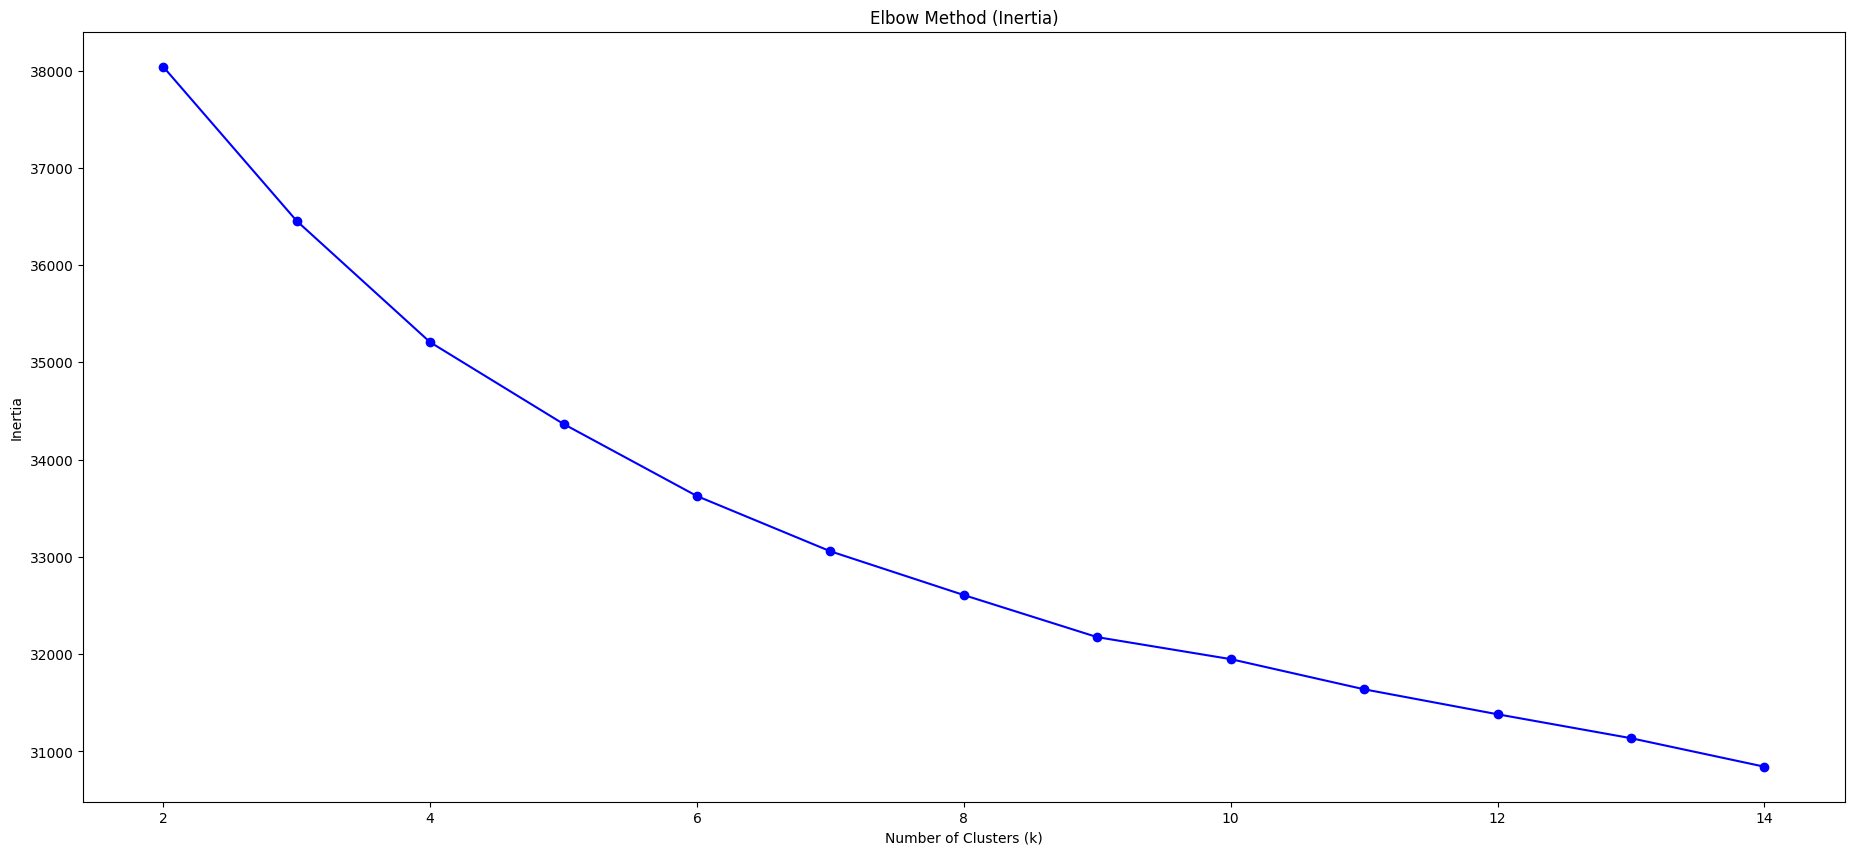

In [34]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', color='b')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

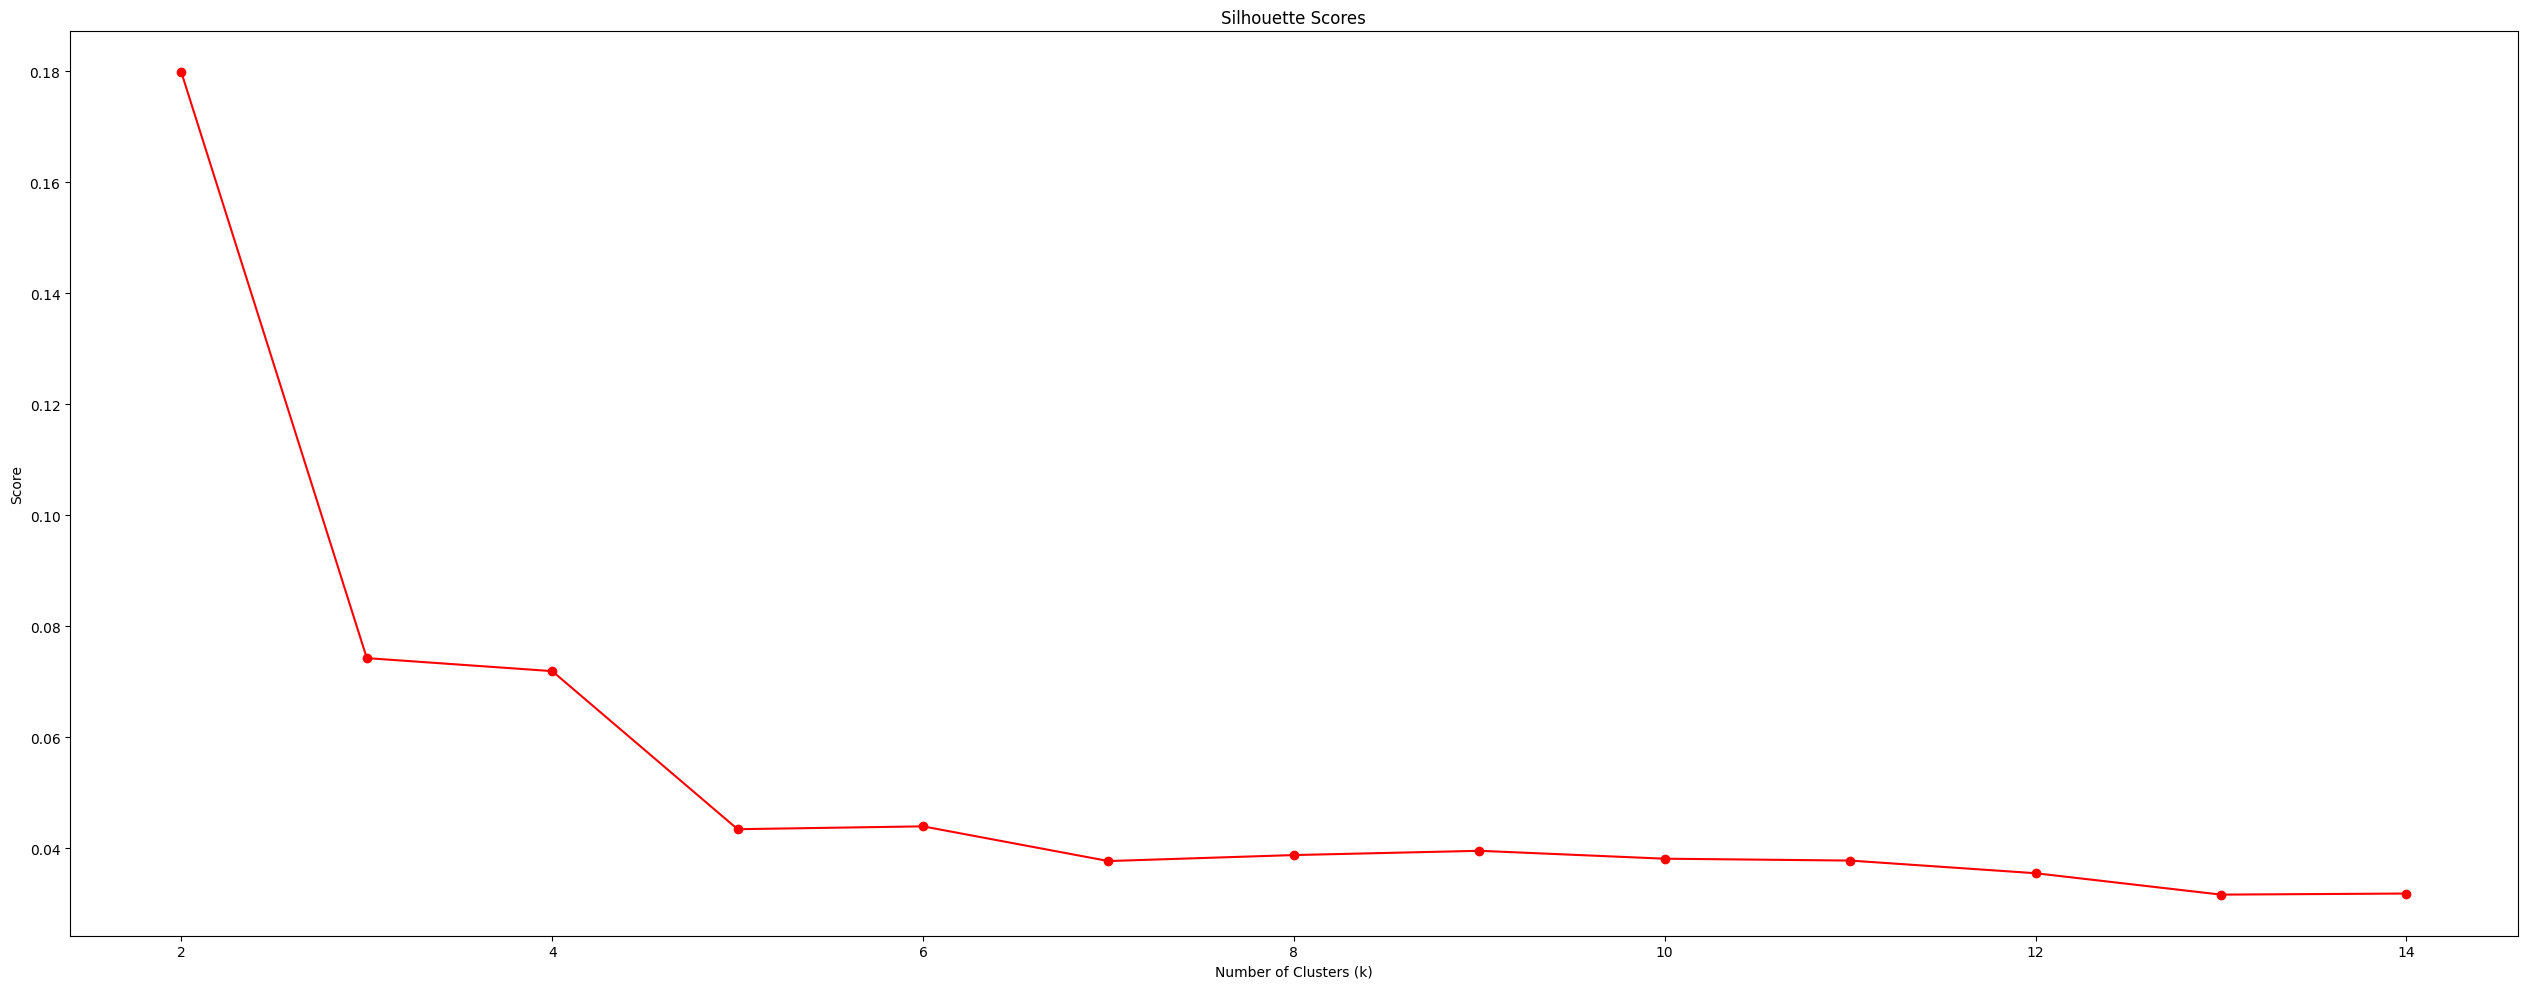

In [35]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_score, marker='o', color='red')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [36]:
cluster = 2
for score in sil_score:
    print(cluster,score)
    cluster+=1

2 0.1797608646719151
3 0.07427888587624071
4 0.07193614198187788
5 0.04346657717564629
6 0.04397924264570717
7 0.037730696835642154
8 0.03880813514274922
9 0.03957695003774856
10 0.03815481624660589
11 0.03781753535502885
12 0.035538166220595295
13 0.0316855809596302
14 0.03187873357925799


In [37]:
k=4
km = KMeans(n_clusters=k,init='k-means++',random_state=42)
km.fit_predict(X)

array([1, 1, 2, ..., 1, 2, 3], dtype=int32)

In [38]:
df = pd.DataFrame({
    "tweet": corpus,
    "cluster": km.labels_
})

In [39]:
df.head()

,tweet,cluster
0,"[basically, chat, opened, call, log, message, ...",1
1,"[io, watchos, no, icon, twitter, notification,...",1
2,"[dear, god, not, againapplesupport]",2
3,"[hi, buy, call, duty, wwii, steam, today, inst...",1
4,"[hi, safaricom_care, can't, pay, dstv, text, s...",1


In [40]:
for i in range(k):
    print(f"\nCLUSTER {i}")

    cluster_samples = df[df["cluster"] == i]["tweet"].head(10)

    for tweet in cluster_samples:
        print(tweet)


CLUSTER 0
[]
['wth', 'hulu', 'lieee']
['currently', 'booked', 'dl', 'dl']
['mason', '’', 'chipotletweets', 'pumpkin']
['yo', "what'd", "ya'll", 'wit', 'upload']
['atviassist']
['pixel', 'xl']
['mcnuggets', 'yayy']
[]
['safari', 'chrome', 'ie', ':(']

CLUSTER 1
['basically', 'chat', 'opened', 'call', 'log', 'message', 'app', 'opened', 'running', 'background', 'otherwise', 'take', 'twice']
['io', 'watchos', 'no', 'icon', 'twitter', 'notification', 'restart', 'iphone', 'watch', 'notif', 'not', 'help']
['hi', 'buy', 'call', 'duty', 'wwii', 'steam', 'today', 'instant', 'access', 'open', 'beta', 'multiplayer']
['hi', 'safaricom_care', "can't", 'pay', 'dstv', 'text', 'say', 'org', 'unavailable']
['found', 'dead', 'fly', 'ironically', 'not', 'soup', "sainsbury's", 'caesar', 'salad', 'not', 'specified', 'content', 'dressing', 'presumably', 'drawn', 'nectar', 'point']
['idea', 'c', 'operating', 'ba', 'ba', ':)']
['passenger', 'account', 'disabled']
['achievement', 'unlocked', 'forza', 'playin',

## DBSCAN

In [41]:
from sklearn.cluster import DBSCAN

In [42]:
from sklearn.preprocessing import normalize

X_norm = normalize(X)

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X_norm)

In [44]:
db = DBSCAN(eps=0.5,min_samples=5,metric='cosine')
labels = db.fit_predict(X_norm)

In [45]:
if len(np.unique(db.labels_)) > 1:
    print(silhouette_score(X_norm,labels))
else:
    print(np.nan)

0.29850031403656013


In [46]:
np.unique(db.labels_)

array([-1,  0,  1])

## Visualization

In [47]:
from sklearn.manifold import TSNE

In [48]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_2d = tsne.fit_transform(X)

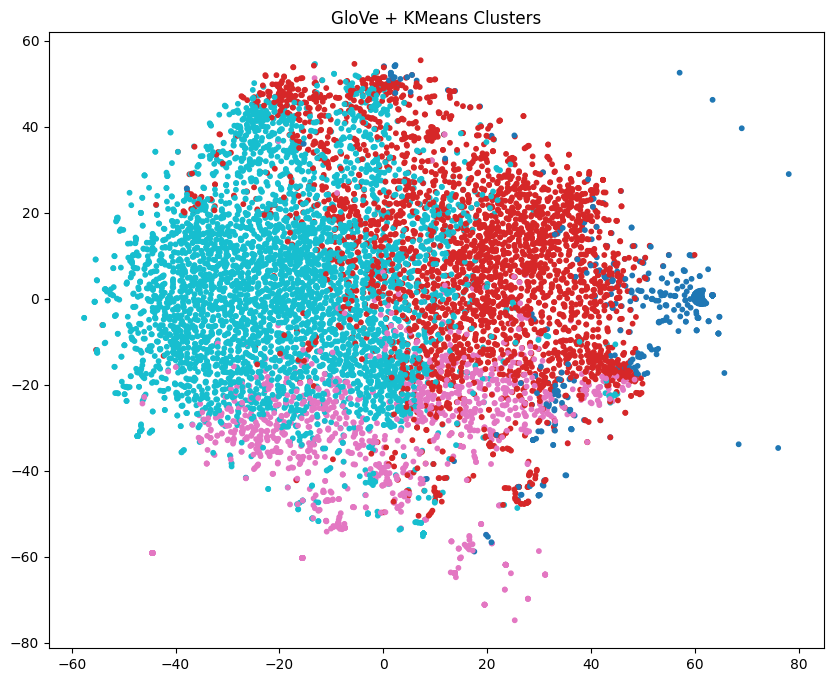

In [49]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=km.labels_,
    cmap='tab10',
    s=10
)

plt.title("GloVe + KMeans Clusters")
plt.show()

In [50]:
cluster_names = {
    0: "Misc Queries",
    1: "Technical Support",
    2: "Customer Complaints",
    3: "Billing & Delivery"
}

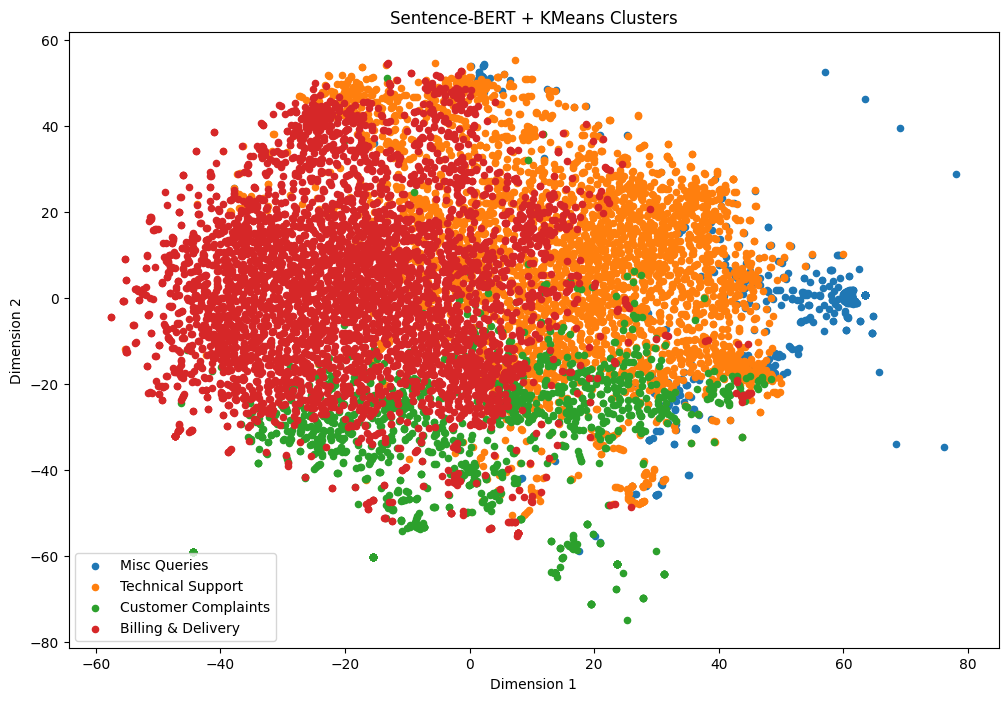

In [51]:
plt.figure(figsize=(12,8))

for cluster_id in np.unique(km.labels_):

    indices = km.labels_ == cluster_id

    plt.scatter(
        X_2d[indices, 0],
        X_2d[indices, 1],
        label=cluster_names[cluster_id],
        s=20
    )

plt.legend()
plt.title("Sentence-BERT + KMeans Clusters")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()